# Exoplanet Classification — Exploratory Data Analysis

**Goal:** classify Kepler Objects of Interest (KOIs) from the NASA Exoplanet Archive cumulative table into three dispositions — `CONFIRMED` exoplanet, `CANDIDATE`, or `FALSE POSITIVE` — using only the tabular vetting and transit-fit features available in the catalog.

This notebook covers Phase 1 of the project: understanding the raw data before any modeling.

**Dataset:** `data/raw/KOI_Cumulative_clean.csv` — 9,564 rows × 140 columns. The `koi_score` column has been deliberately removed from this extract because it is a direct output of the same vetting process that produced the label (target leakage); we do not attempt to reconstruct it.

**Contents**
1. Load & validate
2. Missingness audit
3. Class balance
4. Key feature distributions
5. Correlation structure
6. Class-conditional distributions
7. False-positive vetting flags — keep or drop?


In [1]:
import sys
sys.path.insert(0, "../src")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import data_cleaning as dc

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
FIG_DIR = "../figures"

pd.set_option("display.max_columns", 50)

## 1. Load & validate

`load_raw` checks the file against the expected shape (9564, 140) so a wrong or truncated download fails loudly instead of silently producing a different model.

In [2]:
df = dc.load_raw("../data/raw/KOI_Cumulative_clean.csv")
print(f"Shape: {df.shape}")
df.head(3)

Shape: (9564, 140)


,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_vet_stat,koi_vet_date,koi_pdisposition,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_disp_prov,koi_comment,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_time0,koi_time0_err1,koi_time0_err2,koi_eccen,koi_eccen_err1,...,koi_fwm_stat_sig,koi_fwm_sra,koi_fwm_sra_err,koi_fwm_sdec,koi_fwm_sdec_err,koi_fwm_srao,koi_fwm_srao_err,koi_fwm_sdeco,koi_fwm_sdeco_err,koi_fwm_prao,koi_fwm_prao_err,koi_fwm_pdeco,koi_fwm_pdeco_err,koi_dicco_mra,koi_dicco_mra_err,koi_dicco_mdec,koi_dicco_mdec_err,koi_dicco_msky,koi_dicco_msky_err,koi_dikco_mra,koi_dikco_mra_err,koi_dikco_mdec,koi_dikco_mdec_err,koi_dikco_msky,koi_dikco_msky_err
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,Done,2018-08-16,CANDIDATE,0,0,0,0,q1_q17_dr25_sup_koi,NO_COMMENT,9.488036,0.000028,-0.000028,170.538750,0.002160,-0.002160,2455003.539,0.002160,-0.002160,0.0,NaN,...,0.002,19.462294,0.000014,48.14191,0.00013,0.430,0.510,0.940,0.480,-0.00020,0.00032,-0.00055,0.00031,-0.010,0.13,0.200,0.16,0.200,0.170,0.080,0.130,0.310,0.170,0.320,0.160
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,Done,2018-08-16,CANDIDATE,0,0,0,0,q1_q17_dr25_sup_koi,NO_COMMENT,54.418383,0.000248,-0.000248,162.513840,0.003520,-0.003520,2454995.514,0.003520,-0.003520,0.0,NaN,...,0.003,19.462265,0.000020,48.14199,0.00019,-0.630,0.720,1.230,0.680,0.00066,0.00065,-0.00105,0.00063,0.390,0.36,0.000,0.48,0.390,0.360,0.490,0.340,0.120,0.730,0.500,0.450
2,3,10811496,K00753.01,NaN,CANDIDATE,Done,2018-08-16,CANDIDATE,0,0,0,0,q1_q17_dr25_sup_koi,DEEP_V_SHAPED,19.899140,0.000015,-0.000015,175.850252,0.000581,-0.000581,2455008.850,0.000581,-0.000581,0.0,NaN,...,0.278,19.800321,0.000002,48.13412,0.00002,-0.021,0.069,-0.038,0.071,0.00070,0.00240,0.00060,0.00340,-0.025,0.07,-0.034,0.07,0.042,0.072,0.002,0.071,-0.027,0.074,0.027,0.074


In [3]:
# dtype composition — mostly numeric transit-fit / stellar parameters,
# plus a handful of string identifier and provenance columns
df.dtypes.value_counts()

float64    116
str         16
int64        7
object       1
Name: count, dtype: int64

## 2. Missingness audit

Two distinct patterns to expect here:

- **Fully-null columns** — 19 columns (eccentricity errors, longitude of periastron, ingress duration, semi-major-axis/inclination/equilibrium-temperature errors, model DoF/chi-square, stellar age) are 100% empty in this extract. They carry zero information and are dropped in preprocessing.
- **`kepler_name` sparse by construction** — only confirmed planets receive a Kepler name, so its missingness *is* the label. It must be excluded from features (leakage), which we do in preprocessing.

In [4]:
missing = df.isna().mean().sort_values(ascending=False)
fully_null = missing[missing == 1.0]
print(f"Fully-null columns ({len(fully_null)}):")
print(sorted(fully_null.index.tolist()))

Fully-null columns (19):
['koi_eccen_err1', 'koi_eccen_err2', 'koi_incl_err1', 'koi_incl_err2', 'koi_ingress', 'koi_ingress_err1', 'koi_ingress_err2', 'koi_longp', 'koi_longp_err1', 'koi_longp_err2', 'koi_model_chisq', 'koi_model_dof', 'koi_sage', 'koi_sage_err1', 'koi_sage_err2', 'koi_sma_err1', 'koi_sma_err2', 'koi_teq_err1', 'koi_teq_err2']


In [5]:
# Verify the fully-null set matches the documented drop list exactly
assert set(fully_null.index) == set(dc.FULLY_NULL_COLS), "drop list out of sync with data"
print("Fully-null column list verified against data_cleaning.FULLY_NULL_COLS")

# Confirm koi_score is absent, as documented
assert "koi_score" not in df.columns
print("koi_score confirmed absent (removed at source to prevent leakage)")

Fully-null column list verified against data_cleaning.FULLY_NULL_COLS
koi_score confirmed absent (removed at source to prevent leakage)


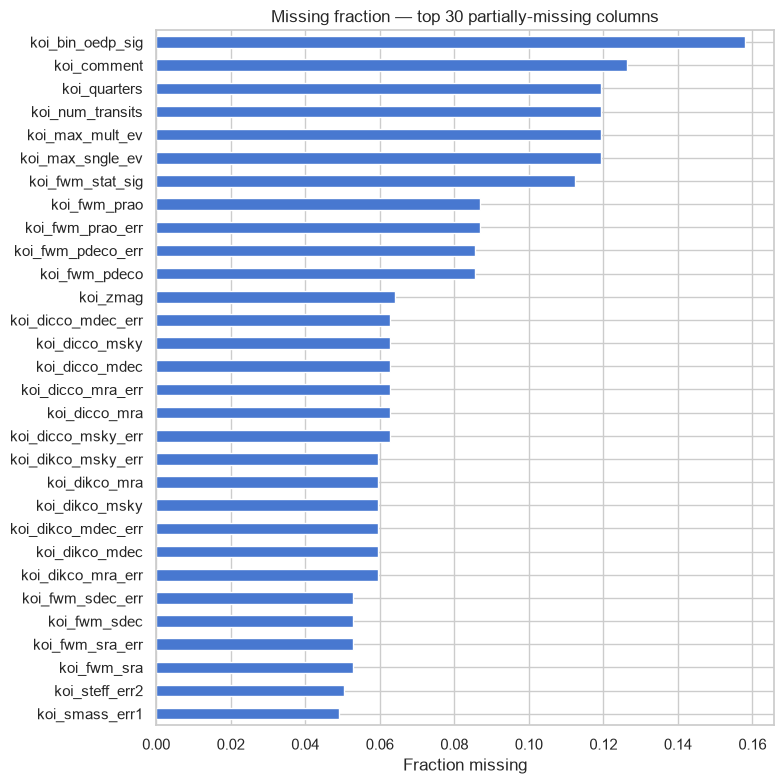

In [6]:
# Missingness among the remaining (informative) columns
informative_missing = missing[(missing > 0) & (missing < 1.0)].drop("kepler_name", errors="ignore")
fig, ax = plt.subplots(figsize=(8, 8))
informative_missing.head(30).sort_values().plot.barh(ax=ax, color="#4878d0")
ax.set_title("Missing fraction — top 30 partially-missing columns")
ax.set_xlabel("Fraction missing")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/missingness.png", dpi=150)
plt.show()

Most partially-missing columns are below ~16% missing, concentrated in secondary vetting statistics (`koi_bin_oedp_sig`) and columns tied to specific pipeline deliveries (`koi_num_transits`, `koi_max_mult_ev` etc. are jointly missing for the ~12% of rows from older catalog deliveries). This level is comfortably handled by median imputation — dropping rows would sacrifice ~1,100+ labeled examples for no clear gain.

## 3. Class balance

The target has three classes with roughly a 2.5 : 1.4 : 1 ratio. FALSE POSITIVE is the majority (~51%). This imbalance is why we optimize **macro F1** rather than accuracy: a model that over-predicts FALSE POSITIVE can look accurate while being useless on CANDIDATE, the smallest and scientifically most interesting class.

koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2747
CANDIDATE         1978
Name: count, dtype: int64
koi_disposition
FALSE POSITIVE    0.506
CONFIRMED         0.287
CANDIDATE         0.207
Name: count, dtype: float64


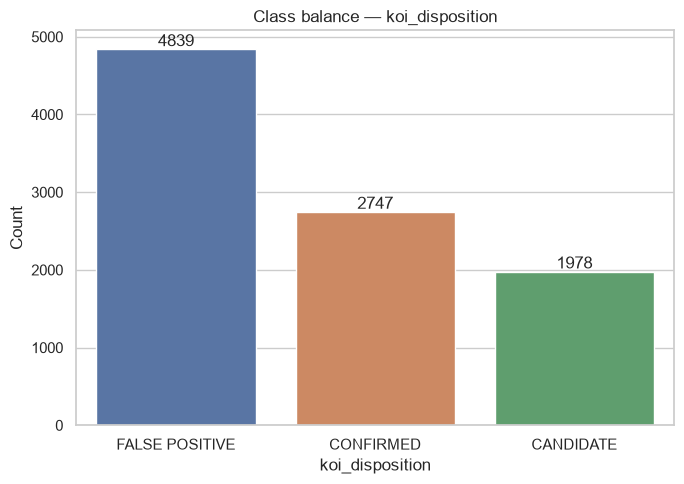

In [7]:
counts = df["koi_disposition"].value_counts()
print(counts)
print((counts / len(df)).round(3))

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="deep", legend=False, ax=ax)
ax.set_title("Class balance — koi_disposition")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 40, str(v), ha="center")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/class_balance.png", dpi=150)
plt.show()

## 4. Key feature distributions

The core transit observables. All are heavily right-skewed — periods span days to years, depths span a few ppm to full stellar eclipses — so we plot on log axes. This skew also motivates two later choices: **median** imputation (robust to the tails) and **log-transform features** for the linear baseline.

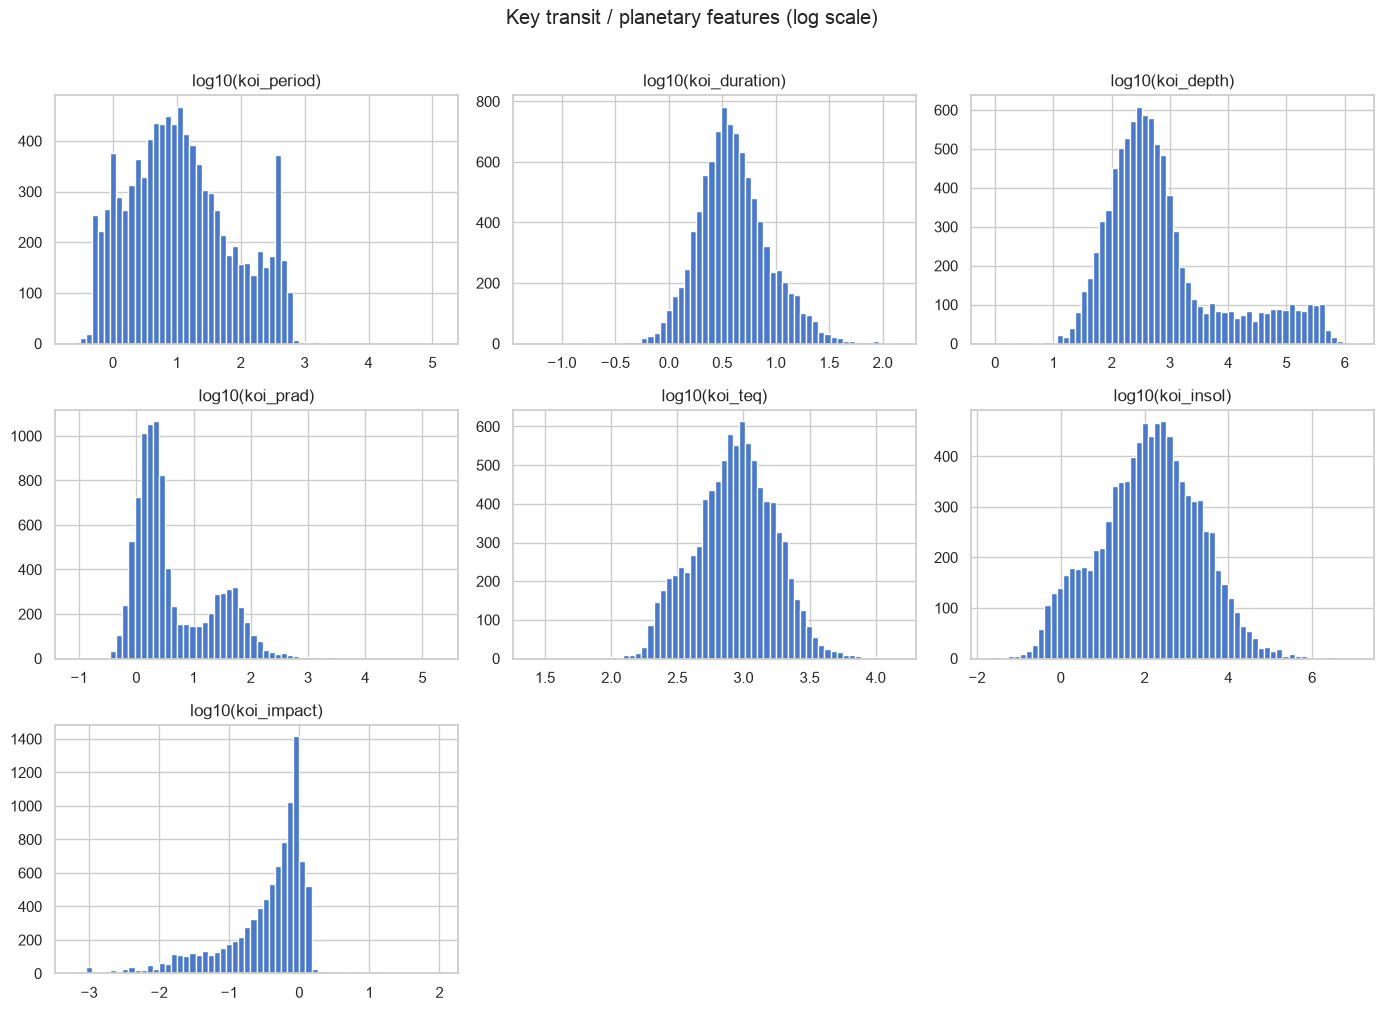

In [8]:
key_features = ["koi_period", "koi_duration", "koi_depth", "koi_prad", "koi_teq", "koi_insol", "koi_impact"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, key_features):
    vals = df[col].dropna()
    vals = vals[vals > 0]
    ax.hist(np.log10(vals), bins=60, color="#4878d0")
    ax.set_title(f"log10({col})")
for ax in axes.flat[len(key_features):]:
    ax.axis("off")
fig.suptitle("Key transit / planetary features (log scale)", y=1.01)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
df[key_features].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
koi_period,9564.0,75.67,1334.74,0.24,2.73,9.75,40.72,129995.78
koi_duration,9564.0,5.62,6.47,0.05,2.44,3.79,6.28,138.54
koi_depth,9201.0,23791.34,82242.68,0.00,159.90,421.10,1473.40,1541400.00
koi_prad,9201.0,102.89,3077.64,0.08,1.40,2.39,14.93,200346.00
koi_teq,9201.0,1085.39,856.35,25.00,539.00,878.00,1379.00,14667.00
koi_insol,9243.0,7745.74,159204.67,0.00,20.15,141.60,870.29,10947554.55
koi_impact,9201.0,0.74,3.35,0.00,0.20,0.54,0.89,100.81


Notable: `koi_prad` (planet radius) has a maximum in the *hundreds of thousands* of Earth radii — physically impossible for a planet. These extreme values are not data errors to clip; they are the fingerprint of eclipsing binaries misfit as planets, i.e. exactly the FALSE POSITIVE signal the model should learn.

## 5. Correlation structure

Two things to check: (a) blocks of redundant columns, (b) anything suspiciously correlated with nothing physical (a leakage smell). The KOI table stores symmetric uncertainty pairs (`_err1` = +err, `_err2` = −err), which we expect to be perfectly anti-correlated — the feature pass later drops the mirrored `_err2` columns.

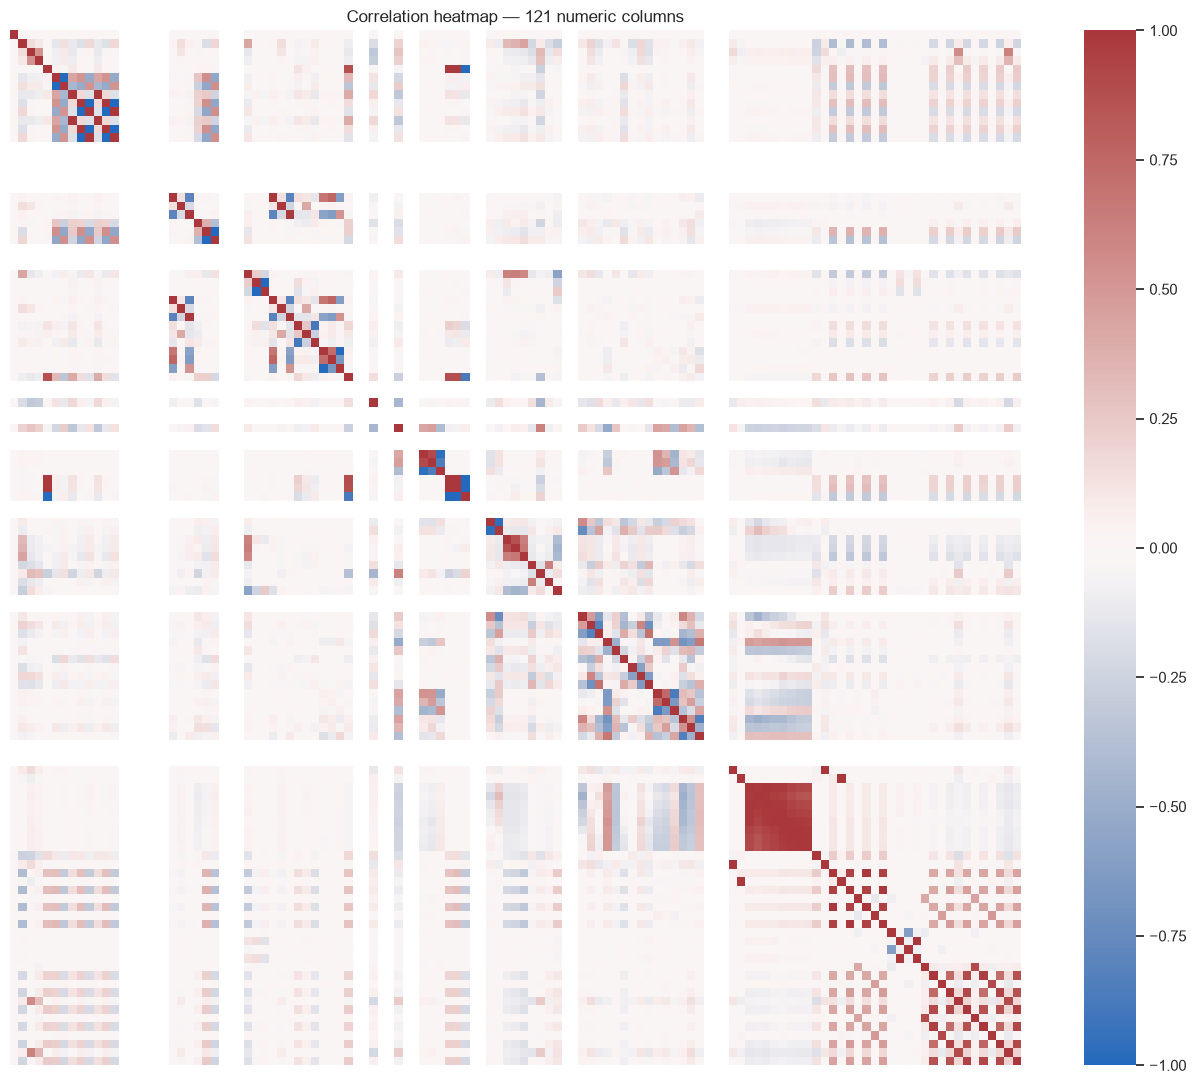

In [10]:
num_df = df.select_dtypes(include=[np.number]).drop(columns=["rowid", "kepid"], errors="ignore")
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap="vlag", center=0, ax=ax, xticklabels=False, yticklabels=False)
ax.set_title(f"Correlation heatmap — {corr.shape[0]} numeric columns")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/correlation_heatmap.png", dpi=150)
plt.show()

In [11]:
# Quantify the _err1/_err2 mirror-redundancy claim
err2_cols = [c for c in num_df.columns if c.endswith("_err2") and c[:-1] + "1" in num_df.columns]
mirror_corr = pd.Series(
    {c: num_df[[c, c[:-1] + "1"]].dropna().corr().iloc[0, 1] for c in err2_cols}
).dropna()
print(f"{(mirror_corr.abs() >= 0.98).sum()} of {len(mirror_corr)} _err2 columns are ~perfectly (anti)correlated with their _err1 twin")
mirror_corr.sort_values().head(10)

6 of 16 _err2 columns are ~perfectly (anti)correlated with their _err1 twin


koi_period_err2     -1.000000
koi_time0bk_err2    -1.000000
koi_time0_err2      -1.000000
koi_duration_err2   -1.000000
koi_depth_err2      -1.000000
koi_dor_err2        -1.000000
koi_insol_err2      -0.853800
koi_steff_err2      -0.824761
koi_prad_err2       -0.660690
koi_srad_err2       -0.653038
dtype: float64

## 6. Class-conditional distributions

Where the signal lives: how do the key features differ across the three dispositions?

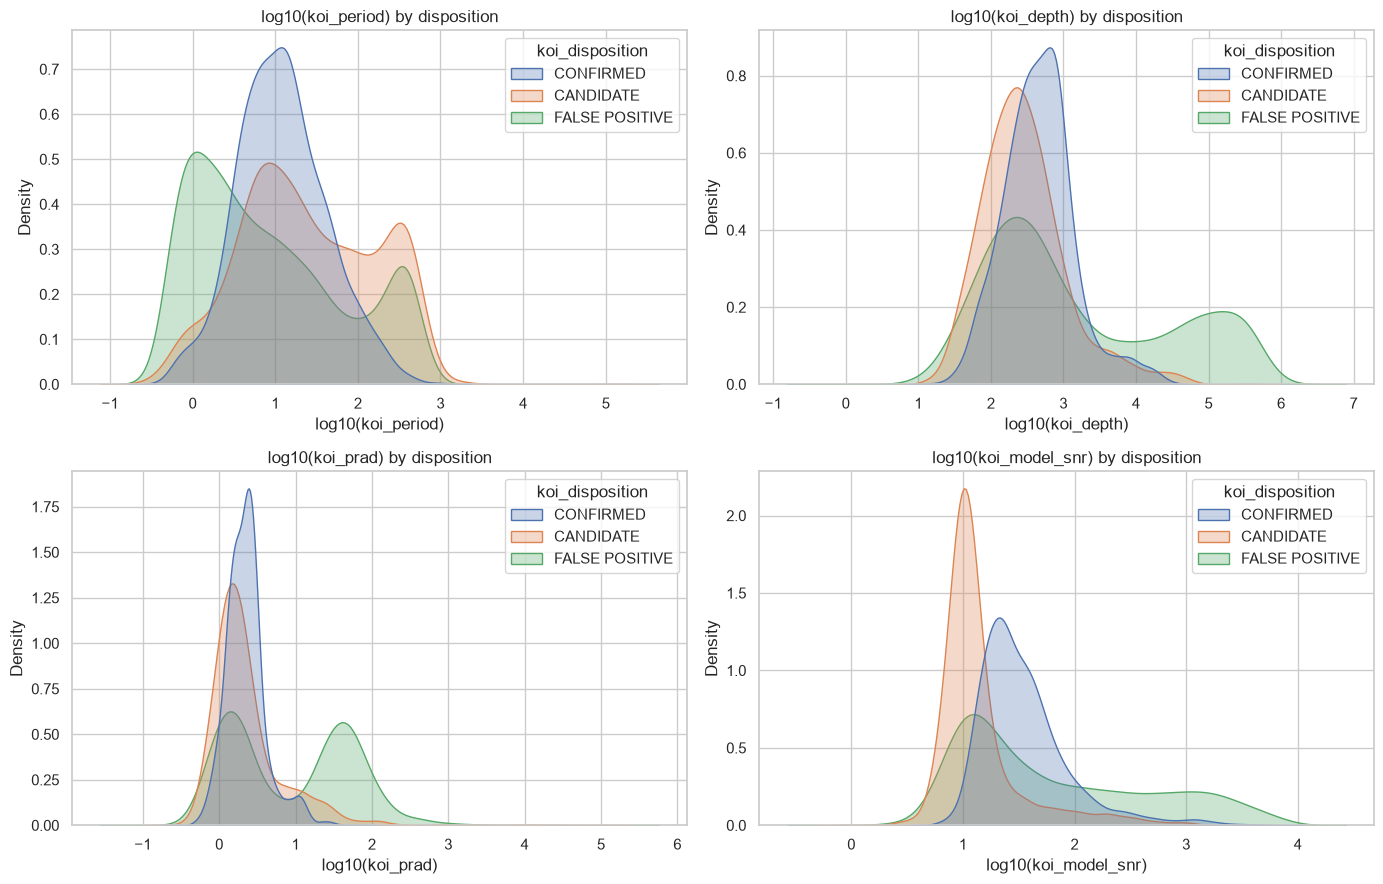

In [12]:
cc_features = ["koi_period", "koi_depth", "koi_prad", "koi_model_snr"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, cc_features):
    sub = df[[col, "koi_disposition"]].dropna()
    sub = sub[sub[col] > 0]
    sns.kdeplot(
        data=sub, x=np.log10(sub[col]), hue="koi_disposition",
        common_norm=False, fill=True, alpha=0.3, ax=ax,
    )
    ax.set_title(f"log10({col}) by disposition")
    ax.set_xlabel(f"log10({col})")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/class_conditional_distributions.png", dpi=150)
plt.show()

Clear physics in these plots:

- **`koi_depth`** — FALSE POSITIVEs skew much deeper: stellar eclipses block far more light than planetary transits.
- **`koi_prad`** — the FALSE POSITIVE distribution has a long tail into stellar-sized "radii"; CONFIRMED planets cluster at 1–20 Earth radii.
- **`koi_model_snr`** — CONFIRMED planets need high signal-to-noise to be confirmed; CANDIDATEs sit at lower SNR (that's largely *why* they remain candidates).
- **`koi_period`** — weaker separation, but very short periods are enriched in false positives (contact binaries).

## 7. Data-leakage exclusion — Kepler vetting flags

`koi_fpflag_nt` (not transit-like), `koi_fpflag_ss` (stellar eclipse), `koi_fpflag_co` (centroid offset), `koi_fpflag_ec` (ephemeris match contamination) are the **output** of Kepler's automated false-positive vetting pipeline. These are *not* legitimate features — they encode the very classification decision we are trying to learn.

**Decision: exclude them from the feature set.** The table below demonstrates how strongly they correlate with the target label, confirming why including them would be data leakage. The pipeline in `src/data_cleaning.py` drops them during cleaning.


In [13]:
# This crosstab demonstrates the data leakage — the flags almost perfectly
# separate FALSE POSITIVEs from the other two classes. This is why they are excluded.
fp_cols = ["koi_fpflag_nt", "koi_fpflag_ss", "koi_fpflag_co", "koi_fpflag_ec"]
flag_any = (df[fp_cols].sum(axis=1) > 0)
pd.crosstab(df["koi_disposition"], flag_any, normalize="index").round(3).rename(
    columns={False: "no flag set", True: ">=1 flag set"}
)


col_0,no flag set,>=1 flag set
koi_disposition,,
CANDIDATE,0.998,0.002
CONFIRMED,0.993,0.007
FALSE POSITIVE,0.020,0.980


Almost every FALSE POSITIVE has at least one flag set, and almost no CONFIRMED planet does. The flags will dominate the FALSE POSITIVE decision — which is fine and physically meaningful — while the harder CONFIRMED vs CANDIDATE boundary must be learned from the transit-fit and stellar columns.

### EDA conclusions carried into preprocessing

1. Drop the 19 fully-null columns and the ID/provenance/leakage columns (incl. `koi_pdisposition`, `kepler_name`).
2. Median-impute remaining numeric missingness (skewed distributions; ≤16% missing).
3. One-hot encode the few low-cardinality categoricals; treat "missing" as its own level for provenance columns.
4. Drop mirrored `_err2` uncertainty columns (perfect anti-correlation with `_err1`).
5. Add log-transformed and ratio features (next notebook).
6. Keep fp-flags, with an ablation to quantify their contribution.